In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/furniture_10k_FINAL (new).csv", sep=';')

In [7]:
df['sales_date_std'] = pd.to_datetime(df['sales_date_std'])

/tmp/ipykernel_4104/723480819.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['sales_date_std'] = pd.to_datetime(df['sales_date_std'])


In [8]:
pivot = pd.pivot_table(
    df,
    values='total_sales',
    index='category',
    columns='status',
    aggfunc='sum'
)

print(pivot)

status       cancelled    completed      refund
category                                       
Dapur        593050000   9380070000   565670000
Kamar Tidur  965985000  17499895000  1000290000
Penyimpanan   90500000   1632355000    89150000
Ruang Kerja  108035000   1808565000    97615000
Ruang Makan  283802500   4783106000   286085000
Ruang Tamu   736080000  12376515000   733020000


In [9]:
cancel = df[df['status'] == 'cancelled']

result_cancel = cancel.groupby('Kota')['order_id'].count()

print(result_cancel)

Kota
Bekasi               67
Bogor                41
Depok                51
Jakarta Barat        48
Jakarta Pusat        58
Jakarta Selatan      53
Jakarta Timur        45
Jakarta Utara        62
Tangerang            48
Tangerang Selatan    46
Name: order_id, dtype: int64


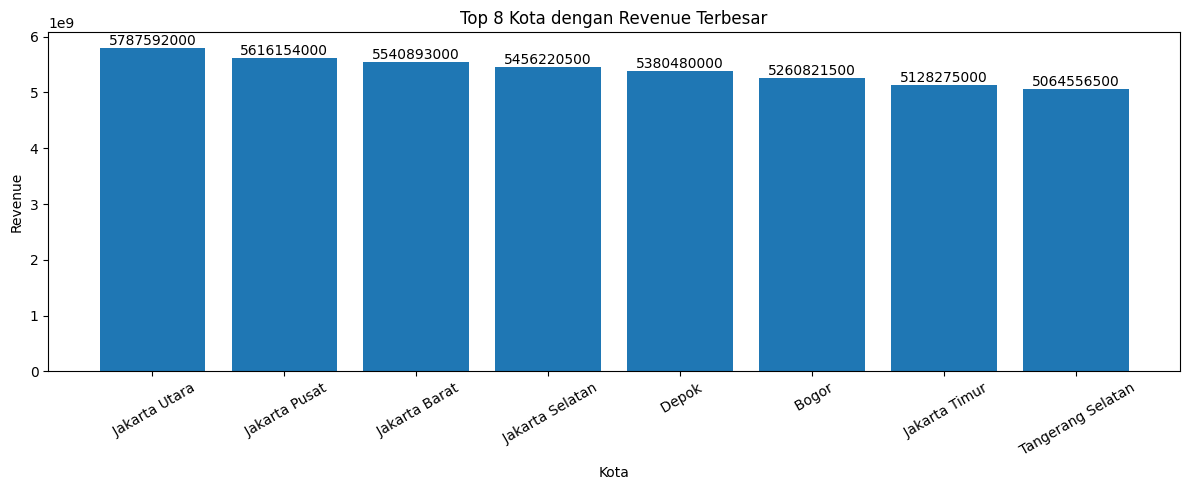

In [10]:
import matplotlib.pyplot as plt
revenue_kota = df.groupby('Kota')['total_sales'].sum().reset_index()

revenue_kota = revenue_kota.sort_values(
    by='total_sales',
    ascending=False
)

top_revenue = revenue_kota.nlargest(8, 'total_sales')

plt.figure(figsize=(12, 5))

bars = plt.bar(top_revenue['Kota'], top_revenue['total_sales'])

plt.xticks(rotation=30)
# Judul dan label
plt.title('Top 8 Kota dengan Revenue Terbesar')
plt.xlabel('Kota')
plt.ylabel('Revenue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             yval,
             ha='center',
             va='bottom')

plt.tight_layout()
# Menampilkan grafik
plt.show()

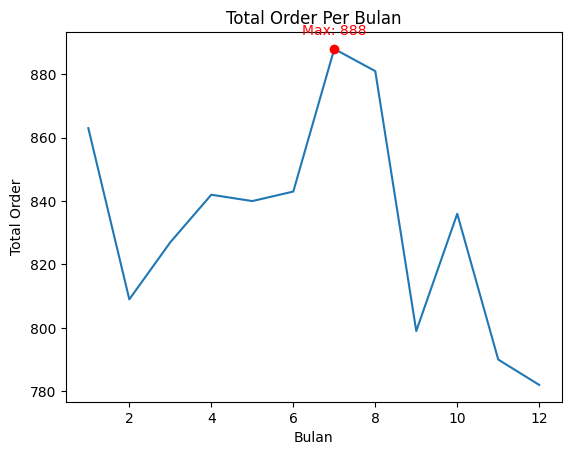

In [11]:
import matplotlib.pyplot as plt

# Ambil bulan
df['bulan'] = df['sales_date_std'].dt.month

total_order = df.groupby('bulan')['order_id'].count().reset_index()

total_order = total_order.sort_values(
    by='bulan',
    ascending=True
)

# Membuat line chart
plt.plot(total_order['bulan'], total_order['order_id'])

# Highlight max value
max_order_month = total_order.loc[total_order['order_id'].idxmax()]
max_bulan = max_order_month['bulan']
max_order = max_order_month['order_id']

plt.plot(max_bulan, max_order, 'ro')
plt.annotate(f'Max: {max_order}', (max_bulan, max_order), textcoords="offset points", xytext=(0,10), ha='center', color='red')

# Judul dan label
plt.title('Total Order Per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Order')

plt.show()